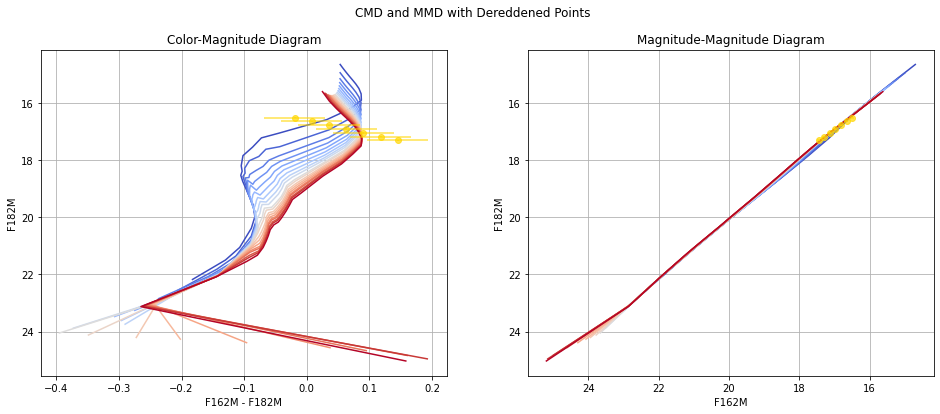

In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening
import csv

# Paths for isochrones and output
iso_dir = 'isochrones/'
output_dir = 'output_diagrams/'
os.makedirs(output_dir, exist_ok=True)

# Estimation variables
star_index = 0  # Set which star in the CSV to analyze

# Define static isochrone parameters
dist = 4500  # Distance in parsecs
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawCardelli(3.1)
filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']
metallicity = 0
level_ages = np.linspace(1, 10, 19) * 1e6  # Define age array
log_age_arr = np.log10(level_ages)

# Load sample magnitudes and errors from CSV
sample_mags = []
sample_errs = []
with open('../s284.csv', mode='r') as file:
    csvFile = csv.reader(file)
    next(csvFile)  # Skip header row
    for lines in csvFile:
        mags = [float(lines[i]) for i in range(1, len(lines), 2)]
        errs = [float(lines[i]) for i in range(2, len(lines), 2)]
        sample_mags.append(mags)
        sample_errs.append(errs)

# Function to generate isochrone grid
def generate_isochrones(AKs):
    return np.array([
        synthetic.IsochronePhot(log_age, AKs, dist, metallicity=metallicity,
                                evo_model=evo_model, atm_func=atm_func,
                                red_law=red_law, filters=filt_list,
                                iso_dir=iso_dir)
        for log_age in log_age_arr
    ])

# Generate isochrone grid for AKs = 0 (no extinction)
isochrone_AKs_00 = generate_isochrones(0.0)

# Wavelength dictionary for JWST filters
filter_wavelengths = {
    "m_jwst_F162M": 1.62,
    "m_jwst_F182M": 1.82,
    "m_jwst_F200W": 2.00,
    "m_jwst_F356M": 3.56,
    "m_jwst_F405N": 4.05
}

# Extract magnitudes and errors for the selected star
m162, m182 = sample_mags[star_index][:2]  # Magnitudes
err162, err182 = sample_errs[star_index][:2]  # Errors

# Define AKs range for dereddening
AKs_values = np.arange(0.4, 1.1, 0.1)  # Adjustable range and step size

# Store dereddened magnitudes
dereddened_mags = []
for AKs_ref in AKs_values:
    m162_dered = m162 - red_law.Cardelli89(filter_wavelengths["m_jwst_F162M"], AKs_ref)
    m182_dered = m182 - red_law.Cardelli89(filter_wavelengths["m_jwst_F182M"], AKs_ref)
    dereddened_mags.append((m162_dered, m182_dered))

# Compute errors in color (m162 - m182) and in F182M magnitude
color_err = np.sqrt(err162**2 + err182**2)  # Propagate errors in color
mag_err = err182  # Vertical error is just the F182M error

# Plot function with dereddened points
def plot_cmd_mmd_with_dereddening(isochrone_grid, dered_mags, ref_errs, title, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    cmap = plt.get_cmap("coolwarm")

    # Plot Color-Magnitude Diagram (CMD)
    for i, instance in enumerate(isochrone_grid):
        color = cmap(i / (len(isochrone_grid) - 1))
        ax1.plot(instance.points["m_jwst_F162M"] - instance.points["m_jwst_F182M"],
                 instance.points["m_jwst_F182M"], color=color)
    
    for i, (m162_d, m182_d) in enumerate(dered_mags):
        ax1.errorbar(m162_d - m182_d, m182_d, xerr=ref_errs[0], yerr=ref_errs[1],
                     fmt='o', color='gold', alpha=0.7)
    
    ax1.set_xlabel("F162M - F182M")
    ax1.set_ylabel("F182M")
    ax1.invert_yaxis()
    ax1.grid(True)
    ax1.set_title("Color-Magnitude Diagram")

    # Plot Magnitude-Magnitude Diagram (MMD)
    for i, instance in enumerate(isochrone_grid):
        color = cmap(i / (len(isochrone_grid) - 1))
        ax2.plot(instance.points["m_jwst_F162M"], instance.points["m_jwst_F182M"], color=color)
    
    for i, (m162_d, m182_d) in enumerate(dered_mags):
        ax2.errorbar(m162_d, m182_d, xerr=ref_errs[0], yerr=ref_errs[1],
                     fmt='o', color='gold', alpha=0.7)
    
    ax2.set_xlabel("F162M")
    ax2.set_ylabel("F182M")
    ax2.invert_xaxis()
    ax2.invert_yaxis()
    ax2.grid(True)
    ax2.set_title("Magnitude-Magnitude Diagram")

    plt.suptitle(title)
    # plt.savefig(os.path.join(output_dir, filename))
    plt.show()

# Plot CMD and MMD with dereddened points
plot_cmd_mmd_with_dereddening(isochrone_AKs_00, dereddened_mags, [color_err, mag_err],
                              "CMD and MMD with Dereddened Points", "CMD_MMD_DEREDDENED.png")


In [52]:
from scipy.stats import chi2

# Degrees of freedom (DOF = number of filters - 1)
DOF = len(filt_list) - 1
CHI_CRITICAL = chi2.ppf(0.95, DOF) / DOF  # Adjust for reduced chi-squared threshold

# Function to compute chi-squared
def chi_square_with_errors(isochrone_grid, observed_mags, observed_errs):
    chi_sq_grid = np.zeros((len(isochrone_grid), len(isochrone_grid[0].points[filters[0]])))
    
    for i, instance in enumerate(isochrone_grid):
        for j in range(len(instance.points[filters[0]])):
            model_mags = np.array([instance.points[filt][j] for filt in filters])
            chi_sq_grid[i, j] = np.sum(((observed_mags - model_mags) / observed_errs) ** 2)
    
    return chi_sq_grid / DOF  # Compute reduced chi-squared

# Loop through AKs values and generate heatmaps
for AKs_ref in AKs_values:
    # Deredden observed magnitudes
    m162_dered = m162 - red_law.Cardelli89(filter_wavelengths["m_jwst_F162M"], AKs_ref)
    m182_dered = m182 - red_law.Cardelli89(filter_wavelengths["m_jwst_F182M"], AKs_ref)
    observed_mags = np.array([m162_dered, m182_dered])
    observed_errs = np.array([err162, err182])
    
    # Compute reduced chi-squared
    reduced_chi_sq = chi_square_with_errors(isochrone_AKs_00, observed_mags, observed_errs)

    # Extract mass values for each isochrone
    masses = np.array([[star['mass'] for star in iso.points] for iso in instances])

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 8))
    norm = LogNorm(vmin=max(np.min(reduced_chi_sq), 1e-3), vmax=np.max(reduced_chi_sq))
    cmap = plt.get_cmap('coolwarm')
    
    # Scatter plot with chi-square gradient
    sc = ax.scatter(
        np.repeat(level_ages, reduced_chi_sq.shape[1]), 
        masses.flatten(), c=reduced_chi_sq.flatten(), cmap=cmap, norm=norm, s=50, edgecolor='k', linewidth=0.5
    )
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Chi-Squared Value')

    # Apply logarithmic scale to y-axis
    ax.set_yscale('log')

    # Contour plot for chi-square threshold
    contour = plt.contour(level_ages, masses[0], reduced_chi_sq.T, levels=[5.991], colors=['black'], linewidths=2.5)
    ax.clabel(contour, inline=True, fontsize=12)

    # Labels and styling
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Mass (M☉)')
    ax.set_title(f'Age-Mass Diagram with Chi-Squared Contouring (AKs = {AKs})')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Axis padding
    x_padding = 0.1 * (level_ages[-1] - level_ages[0])
    y_padding_factor = 0.1
    ax.set_xlim(level_ages[0] - x_padding, level_ages[-1] + x_padding)
    ax.set_ylim(np.min(masses) * (1 - y_padding_factor), np.max(masses) * (1 + y_padding_factor))

    # Save the figure
    # plt.savefig(f"{output_dir}/chi_squared_AKs_{AKs_ref:.1f}.png")
    plt.savefig(f"{output_dir}/chi_squared_AKs_{AKs_ref:.1f}.png", facecolor='white')
    plt.close()

/tmp/ipykernel_41874/353226284.py:49: UserWarning: No contour levels were found within the data range.
  contour = plt.contour(level_ages, masses[0], reduced_chi_sq.T, levels=[5.991], colors=['black'], linewidths=2.5)
